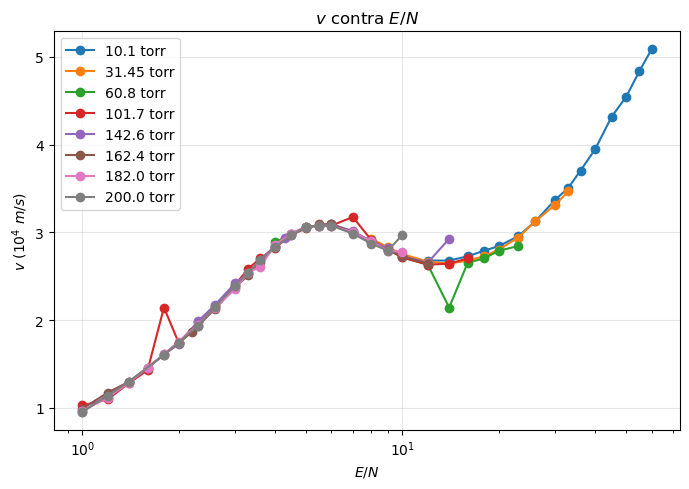

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Leer datos
df = pd.read_csv("../datos/cascada_extendido.csv")
d=3 #cm

# Convertir columnas con coma decimal a float
#df["E/N"] = df["E/N"].astype(str).str.replace(",", ".", regex=False).astype(float)
#df["T_micro"] = df["T_micro"].astype(str).str.replace(",", ".", regex=False).astype(float)

# Graficar T contra E/N, separando por presión
plt.figure(figsize=(7, 5))

def seleccion(presiones_elegidas):
    if len(presiones_elegidas) == 0:
        df_condicional = df.groupby("presion_tor")
    else:
        df_filtrado = df[df["presion_tor"].isin(presiones_elegidas)]
        df_condicional= df_filtrado.groupby("presion_tor")
    return df_condicional
    
#10.1, 31.45, 60.8, 101.7, 142.6, 162.4, 182, 200
presiones=[]

for presion, grupo in seleccion(presiones):
    v = d / grupo["T_micro"]

    plt.plot(
        grupo["E/N"],
        v,
        marker="o",
        linestyle="-",
        label=f"{presion} torr"
    )

plt.xlabel(r"$E/N$")
plt.ylabel(r"$v \ (10^4 \ m/s)$")
plt.title(r"$v$ contra $E/N$")
plt.xscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()